# Colour Models and Spaces
## Code Walkthrough
### Group 1

# ATTENTION GIRLIES!!

REGARDING NAMING CONVENTIONS PLEASE USE:
* 'img_rgb' - to use source image (defined in first/setup cell)
* 'img_norm' - to use the normalised float version (if you even need it, dunno)
* 'show_images' - use this for displaying any images especially when showing in grid fashion 

GRACIAS <3

The purpose of this walkthrough is to show the practicle code that is required to implement different colour spaces, show their varying purposes, and converting between them.

Starting by importing the necessary libraries and loading a consistent test image that will be used throughout every conversion in this section. Using the same image allows direct visual comparison across all colour spaces.

Note that the OpenCV library loads images to BGR by default so the image needs to be converted into RGB when loading.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image - OpenCV reads as BGR by default, so we convert immediately
img_bgr = cv2.imread('test_image.png')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Normalised float version [0,1] used in manual calculations
img_norm = img_rgb.astype(np.float32) / 255.

The helper function below will be used throughout for displaying images.

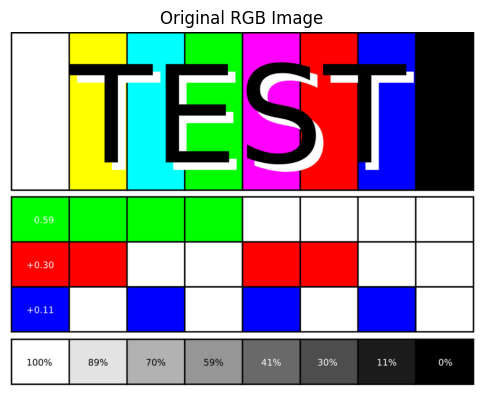

In [2]:
def show_images(images, titles, cmap_list=None):
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    if n == 1:
        axes = [axes]
    for i, (img, title) in enumerate(zip(images, titles)):
        cmap = cmap_list[i] if cmap_list else None
        axes[i].imshow(img, cmap=cmap)
        axes[i].set_title(title)
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

show_images([img_rgb], ['Original RGB Image'])

# 1. RGB
*insert explanation / short intro for rgb and when to implement*

possible content:
* splitting and manipulating individual r,g,b channels
* loading an image in openCV (bgr by default - show 'error')
* channel histograms and clipping (bgr vs rgb channel order problem)

In [3]:
# code to implement rgb

# 2. HSV — Hue, Saturation, Value

RGB is great for displays, but not for *describing colour the way humans see it*. In RGB, the exact values of a “pink” pixel can change a lot depending on lighting, shadows, or camera settings.

HSV solves this by separating colour into three more intuitive parts:

- **Hue (H)** — the actual colour *type* (red, green, blue, etc.), arranged around a colour wheel from 0°–360°.
- **Saturation (S)** — how *vivid* or washed-out the colour is. Low saturation looks grey; high saturation looks rich and vibrant.
- **Value (V)** — the *brightness* of the colour, from black to full brightness.

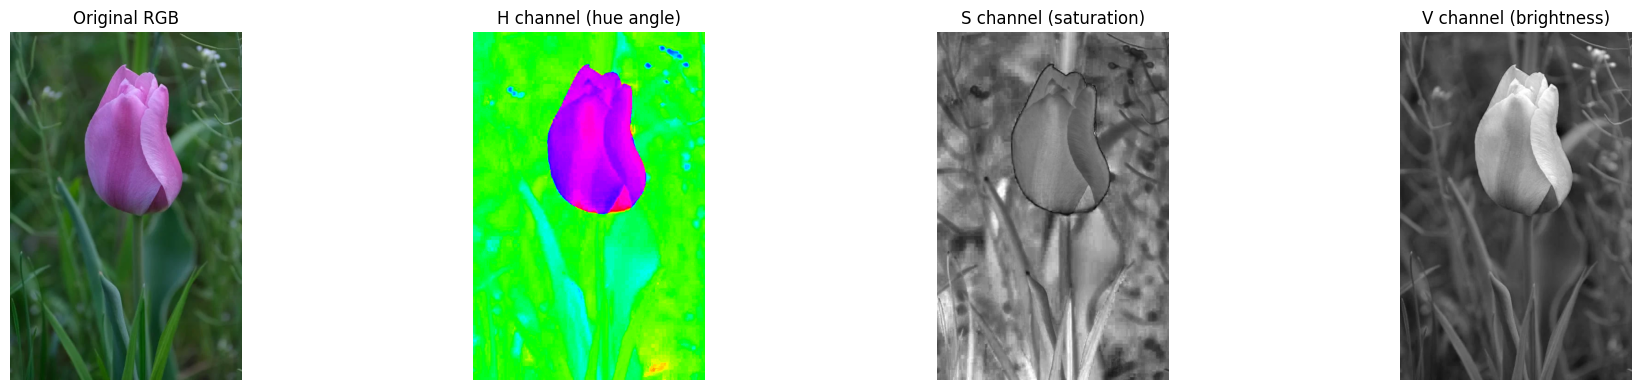

In [4]:
img_tulip_bgr = cv2.imread('tulip.png')
img_tulip_rgb = cv2.cvtColor(img_tulip_bgr, cv2.COLOR_BGR2RGB)
img_tulip_hsv = cv2.cvtColor(img_tulip_rgb, cv2.COLOR_RGB2HSV)

# Split into individual channels
H_ch = img_tulip_hsv[:,:,0]
S_ch = img_tulip_hsv[:,:,1]
V_ch = img_tulip_hsv[:,:,2]

show_images(
    [img_tulip_rgb, H_ch, S_ch, V_ch],
    ['Original RGB', 'H channel (hue angle)', 'S channel (saturation)', 'V channel (brightness)'],
    cmap_list=[None, 'hsv', 'gray', 'gray']
)

## HSV in OpenCV — What's Different

OpenCV implements HSV with two important differences from the textbook definition that will silently break your code if you aren't aware of them.

### Range scaling

|               | Standard HSV | OpenCV |
| :----------- | :------: | ----: |
| Hue        |   0° – 360°   |   0 – 179   |
| Saturation |   0.0 – 1.0   |   0 – 255   |
| Value    |   0.0 – 1.0   |   0 – 255   |

Hue for standard HSV is a full rotation around the colour wheel however in OpenCV it was halved to fit in an 8-bit unsigned integer

This means pure red, which sits at 0° and 360° in standard HSV, sits at 0 and 179 in OpenCV. If you look up a hue threshold online and apply it directly without halving, your mask will select the wrong colours entirely. Always divide standard hue values by 2 before passing them to cv2.inRange().

### Cylinder, not cone

The textbook model of HSV is a cone: the colour circle is widest at the top (full brightness) and tapers to a single point at the bottom (black). This makes geometric sense — a dark pixel can't be saturated.

OpenCV treats HSV as a cylinder: the colour circle stays the same width all the way down, regardless of V. There is no enforcement that low-V pixels must have low S.

The practical consequence is that pixels near black can report high saturation values in OpenCV's encoding, even though visually they have no discernible colour. If you are thresholding on saturation to filter out "colourless" pixels, be aware that very dark pixels may pass your saturation filter and produce unexpected results. Adding a minimum V threshold alongside your S threshold handles this.

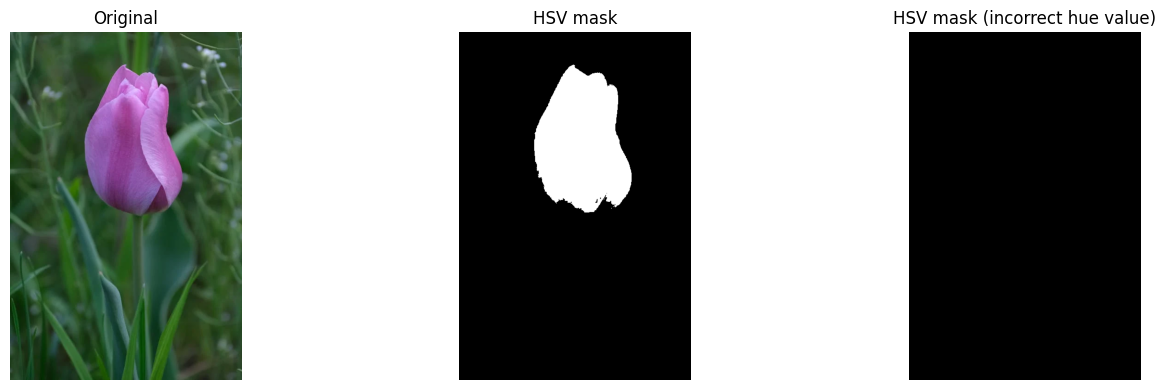

In [5]:
# Correct Range
# Define the hue range for the tulip (pink around H=147) in OpenCV H units
lower_hsv_cv = np.array([130,  50,  80])
upper_hsv_cv = np.array([170, 255, 255])

# inRange produces a binary mask
mask_hsv_cv = cv2.inRange(img_tulip_hsv, lower_hsv_cv, upper_hsv_cv)

# Incorrect Range
lower_hsv = np.array([260,  50,  80])
upper_hsv = np.array([340, 255, 255])

mask_hsv = cv2.inRange(img_tulip_hsv, lower_hsv, upper_hsv)

show_images(
    [img_tulip_rgb, mask_hsv_cv, mask_hsv],
    ['Original',
     'HSV mask',
     'HSV mask (incorrect hue value)'],
    cmap_list=[None, 'gray', 'gray']
)

## Colour masking and segmentation

HSV becomes especially useful for colour-based segmentation — for example, isolating a pink tulip from a green background.

### Using HSV

We define a range of hue values that match pink/magenta and use `cv2.inRange()` to create a binary mask. Because hue is separated from brightness, the tulip can still be detected in both bright and shadowed areas.

In OpenCV, the tulip’s hue is around **H ≈ 147**, so we allow a small tolerance around that value to capture variation across the petals.

### Why RGB struggles

We also try the same task in RGB by matching pixels close to a sampled pink colour, from the center of the tulip. The results are much less reliable because lighting changes alter the R, G, and B values directly.

Shadowed petals often get missed, while some background pixels can accidentally match the threshold. In RGB, colour and brightness are tightly mixed together, making robust segmentation much harder.

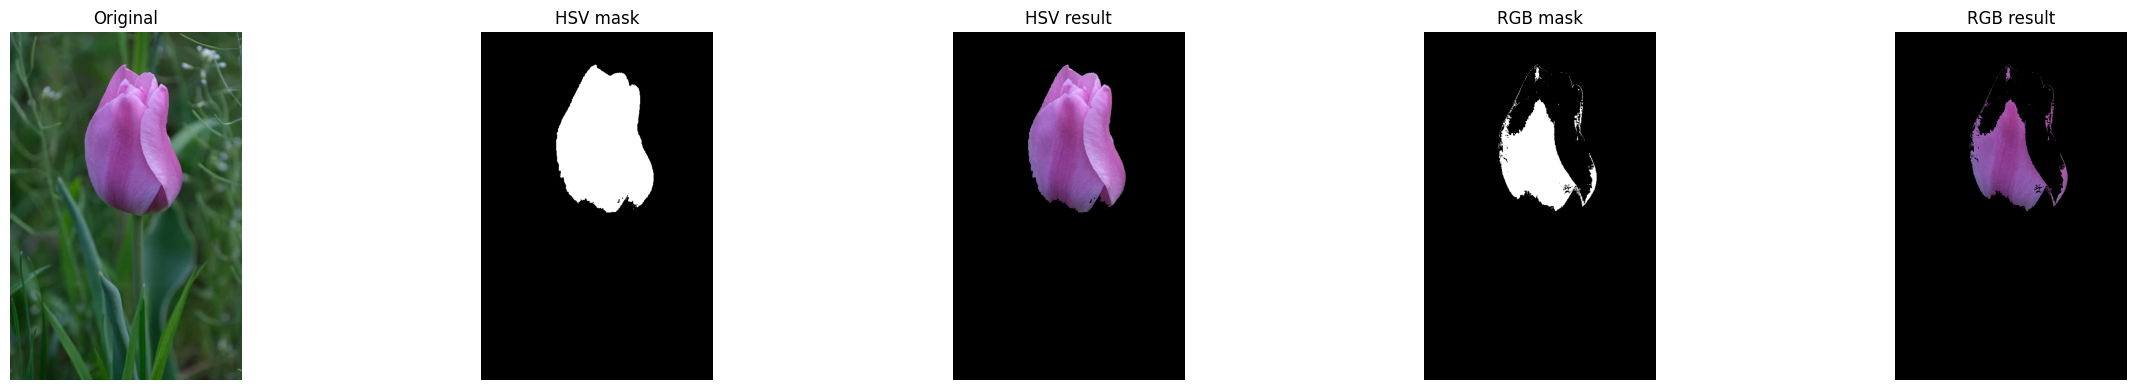


HSV mask: 47,395 pixels selected  (12.6% of image)
RGB mask: 23,840 pixels selected  (6.4% of image)


In [6]:
# HSV masking
lower_hsv = np.array([130,  50,  80])
upper_hsv = np.array([170, 255, 255])

mask_hsv = cv2.inRange(img_tulip_hsv, lower_hsv, upper_hsv)
result_hsv = cv2.bitwise_and(img_tulip_rgb, img_tulip_rgb, mask=mask_hsv)

# RGB MASKING (for comparison)
# Sample a  pink pixel from the tulip centre
sample_pixel = img_tulip_rgb[250, 250].astype(np.float32)

# Accept pixels within Euclidean distance of 60 in RGB space
img_float = img_tulip_rgb.astype(np.float32)
rgb_dist = np.sqrt(np.sum((img_float - sample_pixel) ** 2, axis=2))
mask_rgb = (rgb_dist < 60).astype(np.uint8) * 255
result_rgb = cv2.bitwise_and(img_tulip_rgb, img_tulip_rgb, mask=mask_rgb)

# Display
show_images(
    [img_tulip_rgb, mask_hsv, result_hsv, mask_rgb, result_rgb],
    ['Original',
     'HSV mask',
     'HSV result',
     'RGB mask',
     'RGB result'],
    cmap_list=[None, 'gray', None, 'gray', None]
)

print(f"\nHSV mask: {np.sum(mask_hsv > 0):,} pixels selected  ({100*np.mean(mask_hsv>0):.1f}% of image)")
print(f"RGB mask: {np.sum(mask_rgb > 0):,} pixels selected  ({100*np.mean(mask_rgb>0):.1f}% of image)")

# Observe the HSV mask cleanly captures the full tulip including shadowed regions


## The hue instability problem

HSV has an important limitation: *hue becomes unreliable when saturation is very low.*

In simple terms, grey pixels do not really have a colour. In the HSV model, all greys sit along the centre axis where saturation is zero, so the hue value becomes mathematically undefined.

Most implementations handle this by assigning an arbitrary hue value — often `H = 0`. The problem is that grey or near-white pixels can then accidentally appear to belong to a real colour range.

This can cause two common issues:

- grey regions may be incorrectly detected as coloured objects,
- pale or washed-out colours may become unstable and harder to detect.

**The solution**

When using hue-based masking, always include a **minimum saturation threshold**. In OpenCV, this is done with the `S_min` value in `cv2.inRange()`.

For example, our mask uses `S_min = 50` to ignore near-grey pixels entirely, making the segmentation much more reliable.

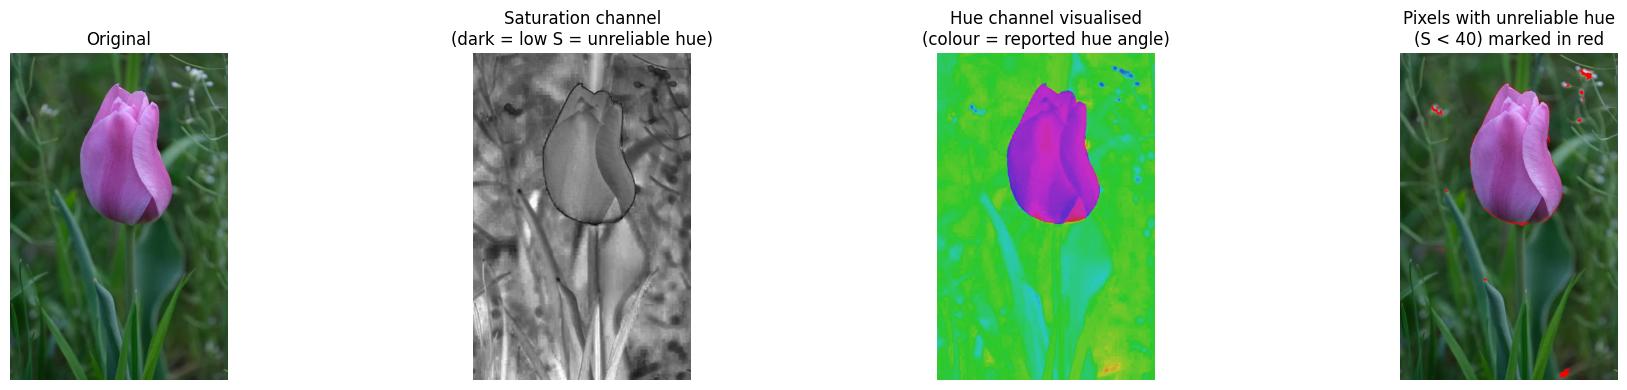

In [7]:
# Visualise hue instability in low-saturation regions
S_ch_float = img_tulip_hsv[:,:,1].astype(np.float32)

# Create a pure hue visualisation: set S=200, V=200 for all pixels, keep only the H channel
hsv_hue_vis = np.stack([
    img_tulip_hsv[:,:,0],
    np.full(img_tulip_hsv.shape[:2], 200, dtype=np.uint8),
    np.full(img_tulip_hsv.shape[:2], 200, dtype=np.uint8)
], axis=2)
hue_visualised = cv2.cvtColor(hsv_hue_vis, cv2.COLOR_HSV2RGB)

# Identify pixels where hue is unreliable (S < 40)
low_sat_mask = S_ch_float < 40
unreliable_overlay = img_tulip_rgb.copy()
unreliable_overlay[low_sat_mask] = [255, 0, 0]  # mark as red

show_images(
    [img_tulip_rgb,
     img_tulip_hsv[:,:,1],
     hue_visualised,
     unreliable_overlay],
    ['Original',
     'Saturation channel\n(dark = low S = unreliable hue)',
     'Hue channel visualised\n(colour = reported hue angle)',
     'Pixels with unreliable hue\n(S < 40) marked in red'],
    cmap_list=[None, 'gray', None, None]
)

# 3. YCbCr - Luma and Chrominance

Unlike RGB, YCbCr separates image information into brightness and colour components. 
This makes it highly effective for image and video compression because human vision is 
more sensitive to brightness detail than colour detail.

YCbCr consists of three channels:

- **Y (Luma)**: brightness and structural image detail
- **Cb**: blue-difference chroma component
- **Cr**: red-difference chroma component

Since most perceptual detail is contained in the Y channel, the chrominance channels can be compressed more aggressively with minimal percieved quality loss. This principle is used in JPEG, MPEG, and H.264 compression systems.

Although Cb and Cr are often visualized using blue and red colour maps, they do not represent actual blue and red images. Instead, they encode chrominance difference relative to luminance.

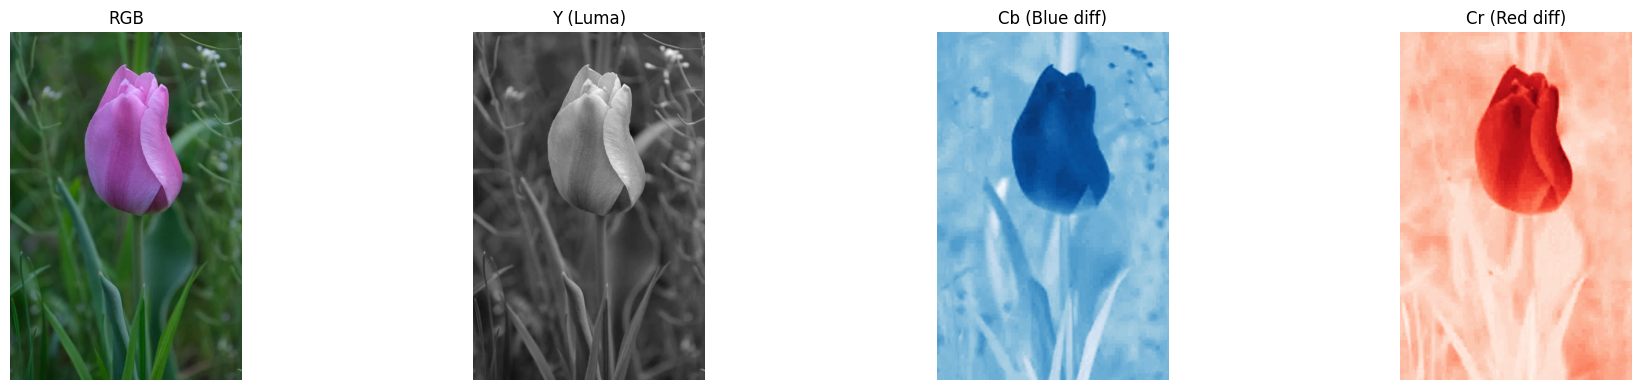

In [8]:
img_tulip_bgr = cv2.imread('tulip.png')
img_tulip_rgb = cv2.cvtColor(img_tulip_bgr, cv2.COLOR_BGR2RGB)

# Convert RGB -> YCbCr
img_ycbcr = cv2.cvtColor(img_tulip_rgb, cv2.COLOR_RGB2YCrCb)

# OpenCV stores channels as Y, Cr, Cb
Y_ch  = img_ycbcr[:,:,0]
Cr_ch = img_ycbcr[:,:,1]
Cb_ch = img_ycbcr[:,:,2]

show_images(
    [img_tulip_rgb, Y_ch, Cb_ch, Cr_ch],
    ['RGB', 'Y (Luma)', 'Cb (Blue diff)', 'Cr (Red diff)'],
    cmap_list=[None, 'gray', 'Blues', 'Reds']
)

The Y channel retains structural detail, while CB and Cr represent chrominance variation. These are visualised as intensity maps rather than true colour images.

## Chroma Subsampling

Chroma subsampling reduces the resolution of the chrominance channels while preserving full resolution in luminance. Since the human visual system is less sensitive to colour detail than brightness, this allows significant data reduction with minimal perceptual loss.

Standard formats include:
- 4:4:4 → no subsampling
- 4:2:2 → reduced horizontal colour resolution
- 4:2:0 → reduced horizontal and vertical colour resolution

To illustrate this, both standard (4:2:0) and extreme subsampling are applied. The extreme case demonstrated visible colour degredation, showing the trade-off between compression and quality.

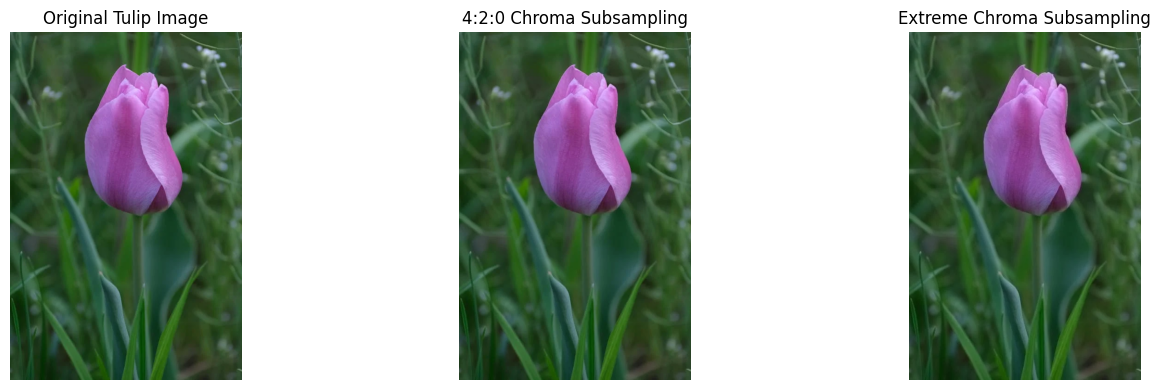

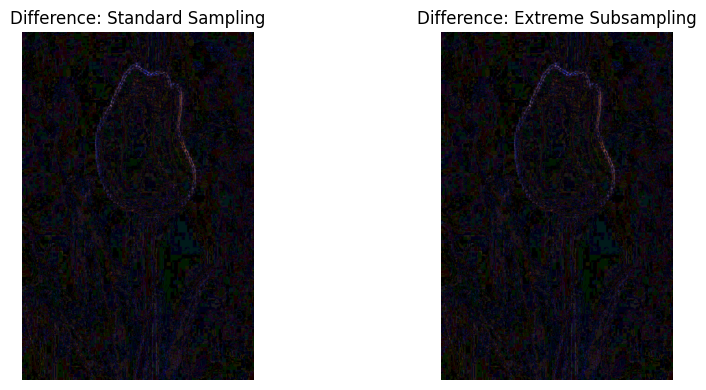

In [9]:
# Standard 4:2:0 subsampling
Cb_small = cv2.resize(Cb_ch, (Cb_ch.shape[1]//2, Cb_ch.shape[0]//2), interpolation=cv2.INTER_LINEAR)
Cr_small = cv2.resize(Cr_ch, (Cr_ch.shape[1]//2, Cr_ch.shape[0]//2), interpolation=cv2.INTER_LINEAR)

Cb_up = cv2.resize(Cb_small, (Cb_ch.shape[1], Cb_ch.shape[0]), interpolation=cv2.INTER_LINEAR)
Cr_up = cv2.resize(Cr_small, (Cr_ch.shape[1], Cr_ch.shape[0]), interpolation=cv2.INTER_LINEAR)

img_subsampled = cv2.merge([Y_ch, Cr_up, Cb_up])
img_subsampled = cv2.cvtColor(img_subsampled, cv2.COLOR_YCrCb2RGB)

# Extreme chroma subsampling
Cb_extreme = cv2.resize(Cb_ch, (Cb_ch.shape[1]//8, Cb_ch.shape[0]//8), interpolation=cv2.INTER_LINEAR)
Cr_extreme = cv2.resize(Cr_ch, (Cr_ch.shape[1]//8, Cr_ch.shape[0]//8), interpolation=cv2.INTER_LINEAR)

Cb_extreme_up = cv2.resize(Cb_extreme, (Cb_ch.shape[1], Cb_ch.shape[0]), interpolation=cv2.INTER_LINEAR)
Cr_extreme_up = cv2.resize(Cr_extreme, (Cr_ch.shape[1], Cr_ch.shape[0]), interpolation=cv2.INTER_LINEAR)

img_extreme = cv2.merge([Y_ch, Cr_extreme_up, Cb_extreme_up])
img_extreme = cv2.cvtColor(img_extreme, cv2.COLOR_YCrCb2RGB)

# Displaying result
show_images(
    [img_tulip_rgb, img_subsampled, img_extreme],
    ['Original Tulip Image', 
     '4:2:0 Chroma Subsampling',
     'Extreme Chroma Subsampling'],
    cmap_list=[None, None, None]
)

# Difference images
diff_normal = np.abs(img_tulip_rgb.astype(np.int16) - img_subsampled.astype(np.int16))
diff_extreme = np.abs(img_tulip_rgb.astype(np.int16) - img_extreme.astype(np.int16))

diff_normal = cv2.normalize(diff_normal, None, 0, 255, cv2.NORM_MINMAX)
diff_extreme = cv2.normalize(diff_normal, None, 0, 255, cv2.NORM_MINMAX)

show_images(
    [diff_normal, diff_extreme],
    ['Difference: Standard Sampling',
     'Difference: Extreme Subsampling'],
    cmap_list=['gray', 'gray']
)


## Skin Detection using YCbCr

YCbCr is commonly used in skin detection because the skin tones tend to cluster within a narrow range of chrominance values, regardless of lighting conditions. This make segmentation in Cb and Cr more robust than RGB-based thresholding.

A threshold range is applied to the Cb and Cr channels to isolate the skin regions. However, since the methods relies purely on chorminance similarity, non-skin regions such as hair or shadowns may also be detected. The difference image appears mostly dark because chroma subsampling introduces only small pixel-level changes, indicating that most structural information is preserved.

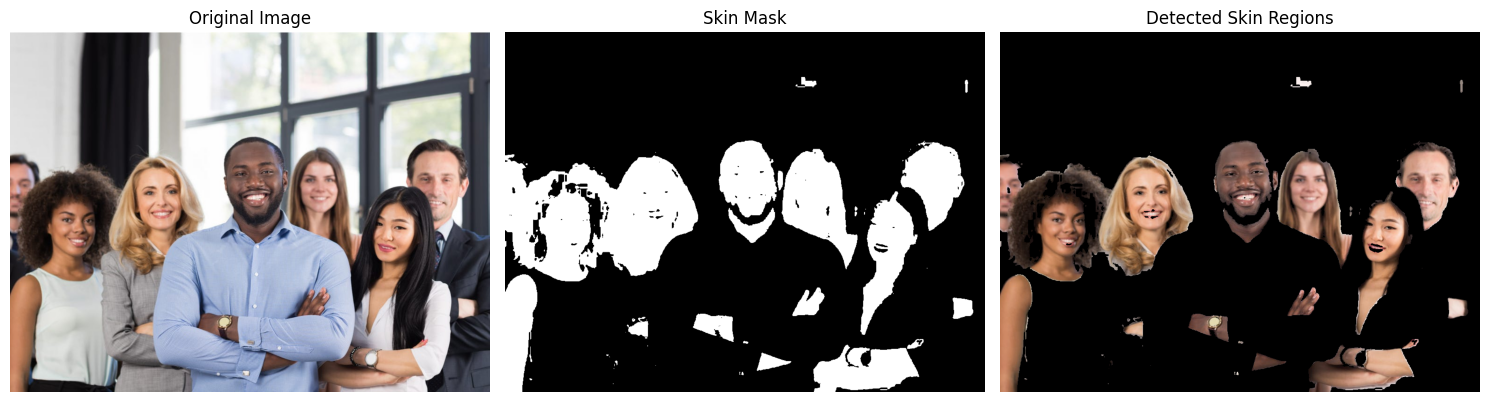

In [10]:
# Load image
img_skin_bgr = cv2.imread('people.jpg')
img_skin_rgb = cv2.cvtColor(img_skin_bgr, cv2.COLOR_BGR2RGB)

# Convert to YCbCr
img_skin_ycbcr = cv2.cvtColor(img_skin_rgb, cv2.COLOR_RGB2YCrCb)

# OpenCV order: Y, Cr, Cb
Y = img_skin_ycbcr[:,:,0]
Cr = img_skin_ycbcr[:,:,1]
Cb = img_skin_ycbcr[:,:,2]

# Skin colour thresholds
skin_mask = cv2.inRange(img_skin_ycbcr, (0, 133, 77), (255, 173, 127))

# Apply mask
skin_detected = cv2.bitwise_and(
    img_skin_rgb,
    img_skin_rgb,
    mask=skin_mask
)

# Display Results
show_images(
    [img_skin_rgb, skin_mask, skin_detected],
    ['Original Image', 'Skin Mask', 'Detected Skin Regions'],
    cmap_list=[None, 'gray', None]
)

## Incorrect Conversion Standard / Colour Cast

Different YCbCr standards (BT.601 vs BT.709) use different conversion coeffecients depending on application. If the wrong, standard is applied, the reconstructed image may exhibit colour shifts known as colour casts.

This occurs because luminance and chrominance are misinterpreted during conversion.

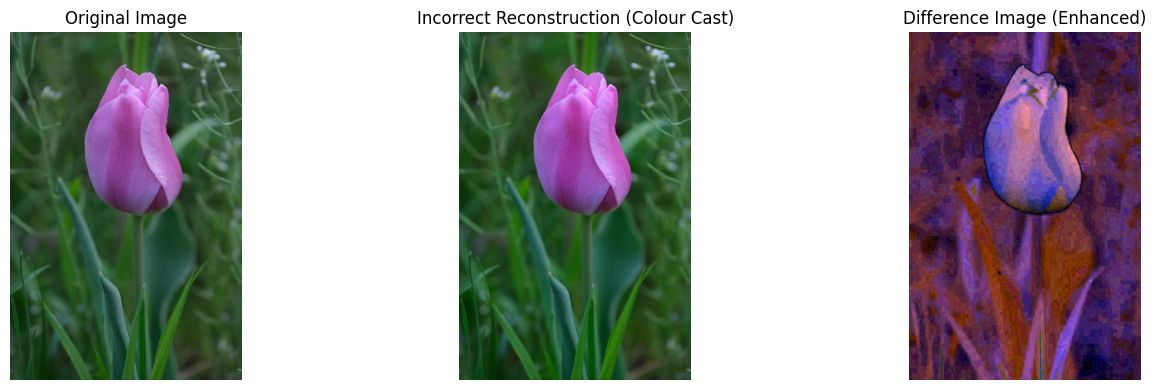

In [11]:
img_ycbcr = cv2.cvtColor(img_tulip_rgb, cv2.COLOR_RGB2YCrCb)

Y  = img_ycbcr[:,:,0].astype(np.float32)
Cr = img_ycbcr[:,:,1].astype(np.float32) - 128
Cb = img_ycbcr[:,:,2].astype(np.float32) - 128

# INTENTIONALLY stronger incorrect reconstruction (colour cast)
R_wrong = Y + 1.8 * Cr
G_wrong = Y - 0.4 * Cb - 0.9 * Cr
B_wrong = Y + 2.2 * Cb

img_wrong = cv2.merge([
    np.clip(R_wrong, 0, 255),
    np.clip(G_wrong, 0, 255),
    np.clip(B_wrong, 0, 255)
]).astype(np.uint8)

# Compute visible difference
diff = cv2.absdiff(img_tulip_rgb, img_wrong)

# Boost visibility (VERY important)
diff_boost = cv2.normalize(diff, None, 0, 255, cv2.NORM_MINMAX)

show_images(
    [img_tulip_rgb, img_wrong, diff_boost],
    ['Original Image',
     'Incorrect Reconstruction (Colour Cast)',
     'Difference Image (Enhanced)'],
     cmap_list=[None, None, 'gray']
)

The difference image represents the pixel-wise absolute difference between the original and reconstructed image. Brighter regions indicate larger colour distirtion, while darker regions indicate minimal changes.

In this example, higher difference mainly in saturated regions such as the flower petals, where chrominance errors have the strongest perceptual effect. The image is normalised to improve visibility, as raw differences are typically small.

# 4. LAB
*explanation / short intro for lab and when to implement*

possible content: 
* channel splitting
* show perceptual colour difference calculations (delta E) - main purpose of lab
* show that equal numerical steps in lab look visibly even (bc the same in rgb isnt)
* show lab based image enhancement vs rgb based and compare

Lab (CIELAB) is a colour space designed around human visual perception rather than hardware or compression efficiency. Unlike RGB, which mixes brightness and colour across all three channels, LAB seperates them completely:

- **L\* (Lightness)** -brightness only, from 0 (black) to 100 (white). Completely independent of colour.
- **a\*** -the green–red opponent axis. Negative= green, positive= red.
- **b\*** -the blue–yellow opponent axis. Negative= blue, positive= yellow.

Its key property is **perceptual uniformity**: equal numerical distances in LAB correspond to roughly equal perceived colour differences. This makes it the standard choice for colour difference measurement (ΔE) and colour correction.

## Channel splitting:

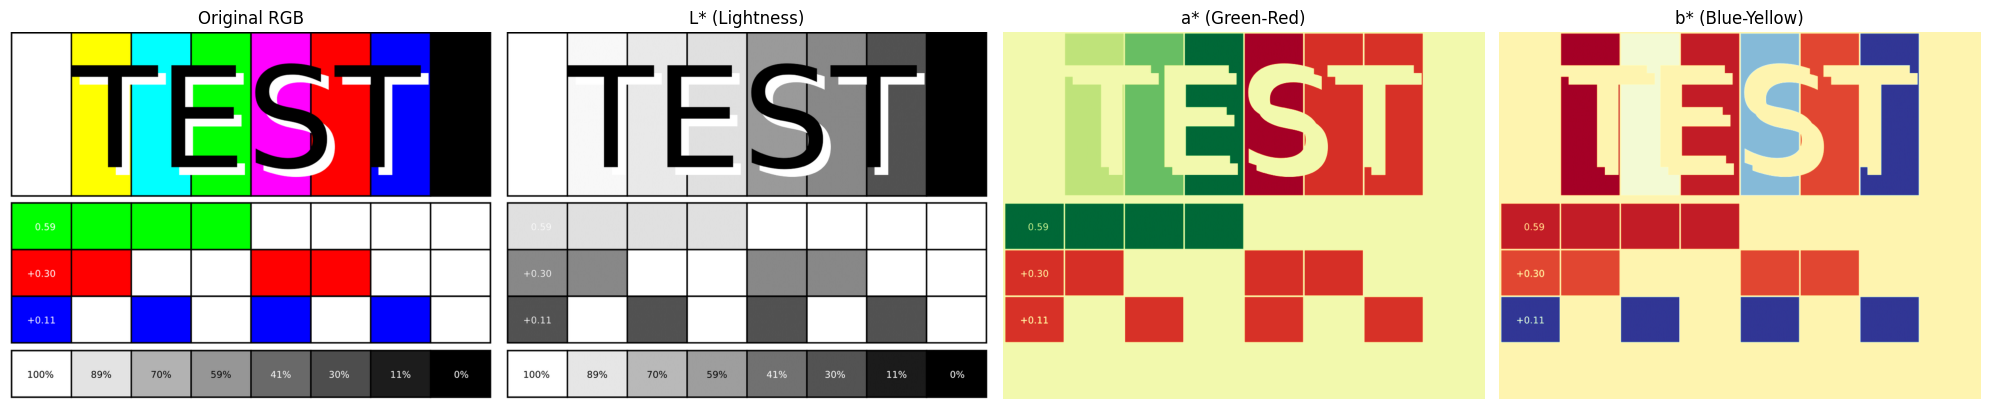

In [15]:
#converting to LAB using OpenCV
#OpenCV expects BGR input for this conversion

img_lab=cv2.cvtColor(img_rgb, cv2.COLOR_RGB2Lab)

#splitting into individual channels
L_ch=img_lab[:,:,0] #L*: 0-100 
a_ch=img_lab[:,:,1] #a*: -128 to 127 
b_ch=img_lab[:,:,2] #b*: -128 to 127

show_images(
    [img_rgb, L_ch, a_ch, b_ch],
    ['Original RGB', 'L* (Lightness)', 'a* (Green-Red)', 'b* (Blue-Yellow)'],
    cmap_list=[None, 'gray', 'RdYlGn_r', 'RdYlBu_r']
)

In [ ]:
# implementation for lab

# 5. Conversions
Colour space conversion is the mathematical process of translating colour data from one representation to another. Each colour space explored in this notebook was designed for a specific purpose: 
* RGB for display
* HSV for human-intuitive colour selection
* YCbCr for compression
* LAB for perceptual uniformity

Moving between them requires precise equations, as using the wrong formula or skipping a step introduces errors that range from subtle colour shifts to completely incorrect output.
This section walks through the conversion equations manually using NumPy, implementing the **classical real-valued floating-point method** throughout. This approach is chosen because the notebook runs in a Python environment where floating-point operations are natively supported, making the underlying mathematics explicit without the hardware constraints that necessitate integer-based or lookup table alternatives. Each forward conversion (RGB to target space) is followed by its inverse, with a difference map confirming the round-trip accuracy. Common implementation errors are demonstrated at the end to show what breaks and why.

### a. RGB -> HSV
RGB stores colour as three correlated light intensities. HSV reorganises this into **Hue** (colour type, 0–360°), **Saturation** (colour purity), and **Value** (brightness). The conversion is nonlinear and requires a piecewise hue calculation based on which RGB component is dominant. We implement this manually first so the mathematics is visible, then verify against OpenCV.

In [ ]:
def rgb_to_hsv_manual(img_norm):
    # Extract R, G, B channels
    R, G, B = img_norm[:,:,0], img_norm[:,:,1], img_norm[:,:,2]

    # Value
    V = np.max(img_norm, axis=2)
    m = np.min(img_norm, axis=2)
    delta = V - m

    # Saturation
    # Safe division: replace 0s with 1 temporarily to avoid divide-by-zero
    V_safe = np.where(V == 0, 1, V) 
    S = np.where(V == 0, 0, delta / V_safe)

    # Hue (piecewise)
    H = np.zeros_like(V)

    # Mask for each dominant channel
    mask_r = (V == R) & (delta != 0)
    mask_g = (V == G) & (delta != 0)
    mask_b = (V == B) & (delta != 0)

    # Compute Hue based on which channel is dominant
    H[mask_r] = 60 * (((G[mask_r] - B[mask_r]) / delta[mask_r]) % 6)
    H[mask_g] = 60 * (((B[mask_g] - R[mask_g]) / delta[mask_g]) + 2)
    H[mask_b] = 60 * (((R[mask_b] - G[mask_b]) / delta[mask_b]) + 4)

    # Achromatic case: delta == 0 means H is undefined (no colour), set to 0 by convention
    H[delta == 0] = 0

    return np.stack([H, S, V], axis=2)

hsv_manual = rgb_to_hsv_manual(img_norm)

# Display the manually computed HSV image (H normalized to [0,1] for display)
print("H range:", hsv_manual[:,:,0].min(), "to", hsv_manual[:,:,0].max())
print("S range:", hsv_manual[:,:,1].min(), "to", hsv_manual[:,:,1].max())
print("V range:", hsv_manual[:,:,2].min(), "to", hsv_manual[:,:,2].max())

Notice how the output range for Hue is 354. This makes sense as 360 would only appear at the exact boundary and most images would not have a pixel that lands precicely there.

Now we verify our manual result against OpenCV's built-in conversion. Note that OpenCV scales Hue to 0–180 (not 0–360) to fit in an 8-bit integer, so we divide our manual H by 2 before comparing.

In [ ]:
# OpenCV HSV: H is 0-180, S and V are 0-255
img_hsv_cv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

# Normalise OpenCV result to match the manual output for comparison
hsv_cv_norm = img_hsv_cv.astype(np.float32)
hsv_cv_norm[:,:,0] /= 180  # H: 0-180 -> 0-1
hsv_cv_norm[:,:,1] /= 255  # S: 0-255 -> 0-1
hsv_cv_norm[:,:,2] /= 255  # V: 0-255 -> 0-1

# Compare - should be near zero
manual_H_norm = hsv_manual[:,:,0] / 360  # H is 0-360 -> 0-1
diff = np.abs(manual_H_norm - hsv_cv_norm[:,:,0])
print("Max H difference between manual and OpenCV:", diff.max())
print("Mean H difference:", diff.mean())

We verify this one conversion against OpenCV to confirm our manual implementation is correct. The same principle applies to the YCbCr and LAB conversions that follow.

### b. HSV -> RGB
To reconstruct RGB from HSV, the process is simply reversed. The hue sector determines which two of the three RGB channels receive the chroma value C and the intermediate value X, and all three channels are then shifted up by the match value m to restore the correct brightness.

In [ ]:
def hsv_to_rgb_manual(hsv):
    H, S, V = hsv[:,:,0], hsv[:,:,1], hsv[:,:,2]

    # Compute intermediate values
    C = V * S
    X = C * (1 - np.abs((H / 60) % 2 - 1))
    m = V - C

    # Initialize R, G, B with zeros
    R, G, B = np.zeros_like(H), np.zeros_like(H), np.zeros_like(H)

    # Determine which sector of the hue circle we're in and assign R, G, B accordingly
    masks = [
        (H < 60),
        (H >= 60) & (H < 120),
        (H >= 120) & (H < 180),
        (H >= 180) & (H < 240),
        (H >= 240) & (H < 300),
        (H >= 300) & (H < 360)
    ]
    # Corresponding RGB values for each sector (before adding m)
    rgb_vals = [
        (C, X, 0), (X, C, 0), (0, C, X),
        (0, X, C), (X, 0, C), (C, 0, X)
    ]

    # Fill in R, G, B based on the masks and corresponding RGB values
    for mask, (r, g, b) in zip(masks, rgb_vals):
        R[mask] = r if np.isscalar(r) else r[mask]
        G[mask] = g if np.isscalar(g) else g[mask]
        B[mask] = b if np.isscalar(b) else b[mask]

    # Add m to each channel and clip to [0,1]
    R, G, B = (R + m), (G + m), (B + m)
    # Stack and clip to [0,1] for valid RGB output
    img_reconstructed = np.clip(np.stack([R, G, B], axis=2), 0, 1)

    return img_reconstructed

img_reconstructed_hsv = hsv_to_rgb_manual(hsv_manual)

show_images(
    [img_norm, img_reconstructed_hsv, np.abs(img_norm - img_reconstructed_hsv) * 10], # Scale difference for visibility
    ['Original RGB', 'Reconstructed from HSV', 'Difference (×10)'],
    cmap_list=[None, None, 'hot']
)

The difference image being mostly if not completely black indicates that the conversion between original and reconstructed images were sucessfully carried out.

### c. RGB -> YCBCR
YCbCr separates luminance (Y) from chrominance (Cb, Cr) using a weighted matrix multiplication. The weights reflect human visual sensitivity: we are more sensitive to green light than blue. The +128 offset centres chrominance values for unsigned 8-bit storage. The standard used here is ITU-R BT.601, designed for standard-definition digital video.

In [ ]:
def rgb_to_ycbcr_manual(img_rgb_uint8):
    # Convert to float for calculation
    img = img_rgb_uint8.astype(np.float32)
    R, G, B = img[:,:,0], img[:,:,1], img[:,:,2]
    
    # Compute Y, Cb, Cr using the standard formula for ITU-R BT.601
    Y  =  0.299  * R + 0.587  * G + 0.114  * B + 16
    Cb = -0.1687 * R - 0.3313 * G + 0.5000 * B + 128
    Cr =  0.5000 * R - 0.4187 * G - 0.0813 * B + 128
    
    # Stack back into an image
    return np.stack([Y, Cb, Cr], axis=2)

ycbcr_manual = rgb_to_ycbcr_manual(img_rgb)

# Display YCbCr channels
Y_ch  = ycbcr_manual[:,:,0]
Cb_ch = ycbcr_manual[:,:,1]
Cr_ch = ycbcr_manual[:,:,2]

# Note: Y alone should look like a greyscale version of the image
print("Y range:", Y_ch.min(), "to", Y_ch.max())
print("Cb range:", Cb_ch.min(), "to", Cb_ch.max())
print("Cr range:", Cr_ch.min(), "to", Cr_ch.max())

### d. YCBCR -> RGB
The inverse applies the offset removals first: Y is shifted by 16 (because BT.601 Y ranges from 16–235, not 0–255) and chrominance channels are uncentred by subtracting 128 before the matrix reconstruction recovers R, G, B.

In [ ]:
def ycbcr_to_rgb_manual(ycbcr):
    # Extract Y, Cb, Cr channels
    Y  = ycbcr[:,:,0]
    Cb = ycbcr[:,:,1]
    Cr = ycbcr[:,:,2]

    # Compute R, G, B using the inverse of the YCbCr formula
    R = 1.000 * (Y - 16) + 1.402 * (Cr - 128)
    G = 1.000 * (Y - 16) - 0.344 * (Cb - 128) - 0.714 * (Cr - 128)
    B = 1.000 * (Y - 16) + 1.772 * (Cb - 128)

    # Clip values to [0,255] and convert to uint8
    img_out = np.clip(np.stack([R, G, B], axis=2), 0, 255).astype(np.uint8)
    return img_out

img_reconstructed_ycbcr = ycbcr_to_rgb_manual(ycbcr_manual)

show_images(
    [img_rgb, 
     img_reconstructed_ycbcr, 
     np.abs(img_rgb.astype(np.float32) - img_reconstructed_ycbcr.astype(np.float32)).astype(np.uint8)],
    ['Original RGB', 'Reconstructed from YCbCr', 'Difference'],
    cmap_list=[None, None, 'hot']
)

### e. RGB -> LAB
Converting to LAB requires two steps with RGB as the starting point. First, the gamma encoding must be removed (linearisation) to get physically meaningful light values. Then a matrix converts to **CIE XYZ**, a device-independent intermediate space. Finally, a nonlinear perceptual mapping produces the LAB coordinates. Skipping the linearisation step is the most common implementation error and produces incorrect L values.

In [ ]:
def rgb_to_lab_manual(img_norm):
    # Step 1: Inverse gamma correction (linearise)
    def linearise(c):
        # sRGB standard linearisation
        return np.where(c <= 0.04045, c / 12.92, ((c + 0.055) / 1.055) ** 2.4)

    # Apply linearisation to each channel
    R = linearise(img_norm[:,:,0])
    G = linearise(img_norm[:,:,1])
    B = linearise(img_norm[:,:,2])

    # Step 2: Linear RGB -> XYZ (D65)
    # Using the standard transformation matrix for sRGB to XYZ
    X = 0.4124564*R + 0.3575761*G + 0.1804375*B
    Y = 0.2126729*R + 0.7151522*G + 0.0721750*B
    Z = 0.0193339*R + 0.1191920*G + 0.9503041*B

    # Step 3: Normalise by D65 white point
    # D65 white point in XYZ is approximately (0.95047, 1.00000, 1.08883)
    X /= 0.95047
    Y /= 1.00000
    Z /= 1.08883

    # Step 4: Nonlinear mapping f(t)
    def f(t):
        # Threshold for linear vs nonlinear
        return np.where(t > 0.008856, t ** (1/3), 7.787 * t + 16/116)

    # Apply f to each of X, Y, Z
    fx, fy, fz = f(X), f(Y), f(Z)

    # Step 5: LAB components
    L = 116 * fy - 16
    a = 500 * (fx - fy)
    b = 200 * (fy - fz)

    return np.stack([L, a, b], axis=2)

lab_manual = rgb_to_lab_manual(img_norm)

# Display LAB channels
L_ch = lab_manual[:,:,0]
a_ch = lab_manual[:,:,1]
b_ch = lab_manual[:,:,2]

print("L* range:", L_ch.min(), "to", L_ch.max())
print("a* range:", a_ch.min(), "to", a_ch.max())
print("b* range:", b_ch.min(), "to", b_ch.max())

### f. LAB -> RGB
The inverse follows the pipeline in reverse: LAB coordinates are unpacked back to normalised XYZ intermediates, the inverse nonlinear function recovers the tristimulus values, the inverse matrix reconstructs linear RGB, and finally gamma correction re-encodes for display.

In [ ]:
def lab_to_rgb_manual(lab):
    # Extract L, a, b channels
    L, a, b = lab[:,:,0], lab[:,:,1], lab[:,:,2]

    # Step 1: LAB -> intermediate
    # Inverse of the f(t) function and the scaling for L, a, b
    fy = (L + 16) / 116
    fx = a / 500 + fy
    fz = fy - b / 200

    # Step 2: Inverse nonlinear function
    def f_inv(t):
        # Inverse of the f(t) function used in LAB conversion
        return np.where(t > 0.206893, t**3, (t - 16/116) / 7.787)

    X = 0.95047 * f_inv(fx)
    Y = 1.00000 * f_inv(fy)
    Z = 1.08883 * f_inv(fz)

    # Step 3: XYZ -> linear RGB
    R =  3.2404542*X - 1.5371385*Y - 0.4985314*Z
    G = -0.9692660*X + 1.8760108*Y + 0.0415560*Z
    B =  0.0556434*X - 0.2040259*Y + 1.0572252*Z

    # Step 4: Gamma correction
    def gamma(c):
        c_safe = np.clip(c, 0, None) # Clip to 0 before power to avoid NaN on negative values
        # negative linear RGB can occur from matrix math on out-of-gamut colours
        # sRGB standard gamma correction
        return np.where(c > 0.0031308,
                        1.055 * (c_safe ** (1/2.4)) - 0.055,
                        12.92 * c)

    # Apply gamma correction and clip to [0,1]
    R, G, B = gamma(R), gamma(G), gamma(B)
    img_out = np.clip(np.stack([R, G, B], axis=2), 0, 1)
    return img_out

img_reconstructed_lab = lab_to_rgb_manual(lab_manual)

show_images(
    [img_norm, img_reconstructed_lab, np.abs(img_norm - img_reconstructed_lab) * 10], # Scale difference for visibility
    ['Original RGB', 'Reconstructed from LAB', 'Difference (×10)'],
    cmap_list=[None, None, 'hot']
)

## What happens when convsersions are done incorrectly?
Here we deliberately introduce the most common conversion errors to show their visual effect.

### a. OpenCV Hue range (0-180 vs 0-360)
OpenCV stores H in 0–180 to fit in a uint8, so if you take a raw OpenCV HSV output and treat it as 0–360 degrees in your own calculations, every hue-based operation will be wrong.

In [ ]:
# Take OpenCV HSV output and mistakenly treat H as 0-360
img_hsv_cv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

# Correct: scale H back to 0-360 before converting
hsv_correct = img_hsv_cv.astype(np.float32)
hsv_correct[:,:,0] *= 2  # 0-180 -> 0-360
hsv_correct[:,:,1] /= 255
hsv_correct[:,:,2] /= 255
reconstructed_correct = hsv_to_rgb_manual(hsv_correct)

# Wrong: treat H as already being 0-360 (it isn't)
hsv_wrong = img_hsv_cv.astype(np.float32)
hsv_wrong[:,:,1] /= 255
hsv_wrong[:,:,2] /= 255
reconstructed_wrong = hsv_to_rgb_manual(hsv_wrong)

show_images(
    [img_norm, reconstructed_correct, reconstructed_wrong],
    ['Original', 'Correct (H scaled to 0-360)', 'Wrong (H treated as 0-360 without scaling)']
)

### b. Not normalising before RGB -> HSV
The manual function expects float input in [0,1]. If a raw uint8 image (0–255) is passed without normalising first, the max/min/delta calculations produce completely wrong V values since it is simply the max channel intensity with no normalisation. Hue and Saturation are not affected because both are calculated from ratios where the scale cancels out.

In [ ]:
# Correct: normalised input
hsv_correct = rgb_to_hsv_manual(img_norm)

# Wrong: passing uint8 directly without normalising
hsv_wrong = rgb_to_hsv_manual(img_rgb.astype(np.float32))  # values 0-255 not 0-1

print("Correct V range:", hsv_correct[:,:,2].min(), "to", hsv_correct[:,:,2].max())
print("Wrong V range:  ", hsv_wrong[:,:,2].min(), "to", hsv_wrong[:,:,2].max())
print("Correct S range:", hsv_correct[:,:,1].min(), "to", hsv_correct[:,:,1].max())
print("Wrong S range:  ", hsv_wrong[:,:,1].min(), "to", hsv_wrong[:,:,1].max())

### c. Skipping gamma linearisation before LAB
Skipping the linearisation step and passing gamma-encoded RGB values directly into the XYZ matrix treats non-linear display values as if they were physical light measurements, producing incorrect XYZ tristimulus values and ultimately a compressed, inaccurate L channel.

In [ ]:
def rgb_to_lab_no_linearise(img_norm):
    # Skip linearisation — use raw normalised values directly
    R, G, B = img_norm[:,:,0], img_norm[:,:,1], img_norm[:,:,2]

    # Use the same RGB->XYZ matrix but on non-linearised RGB
    X = 0.4124564*R + 0.3575761*G + 0.1804375*B
    Y = 0.2126729*R + 0.7151522*G + 0.0721750*B
    Z = 0.0193339*R + 0.1191920*G + 0.9503041*B

    X /= 0.95047; Y /= 1.00000; Z /= 1.08883

    def f(t):
        return np.where(t > 0.008856, t**(1/3), 7.787*t + 16/116)

    L = 116 * f(Y) - 16
    a = 500 * (f(X) - f(Y))
    b = 200 * (f(Y) - f(Z))

    return np.stack([L, a, b], axis=2)

lab_wrong = rgb_to_lab_no_linearise(img_norm)

show_images(
    [lab_manual[:,:,0], lab_wrong[:,:,0], np.abs(lab_manual[:,:,0] - lab_wrong[:,:,0])],
    ['L* — Correct (with linearisation)', 'L* — Wrong (no linearisation)', 'Difference'],
    cmap_list=['gray', 'gray', 'hot']
)

print("L* difference max:", np.abs(lab_manual[:,:,0] - lab_wrong[:,:,0]).max())

### d. Using the wrong BT standard (BT.601 encode, BT.709 decode)
Encoding with BT.601 but decoding with BT.709 introduces a visible colour cast across the entire image, because the two standards use different luminance weights derived from different display primaries. The coefficients are not interchangeable even though the equation structure looks identical.

In [ ]:
# BT.709 decode coefficients (different from BT.601)
def ycbcr_to_rgb_bt709(ycbcr):
    Y  = ycbcr[:,:,0]
    Cb = ycbcr[:,:,1]
    Cr = ycbcr[:,:,2]

    R = Y + 1.5748 * (Cr - 128)
    G = Y - 0.1873 * (Cb - 128) - 0.4681 * (Cr - 128)
    B = Y + 1.8556 * (Cb - 128)

    return np.clip(np.stack([R, G, B], axis=2), 0, 255).astype(np.uint8)

# Encoded with BT.601 but decoded with BT.709
wrong_standard = ycbcr_to_rgb_bt709(ycbcr_manual)

show_images(
    [img_rgb, img_reconstructed_ycbcr, wrong_standard, np.abs(img_rgb.astype(np.float32) - wrong_standard.astype(np.float32))],
    ['Original', 'Correct (BT.601 both ways)', 'Wrong: BT.601 encode / BT.709 decode', 'Difference']
)

# Conclusion/Summary